In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, hamming_loss
from sklearn.metrics import multilabel_confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/okcupid_cleaned_redflags.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,speaks,full_bio,clean_bio,bio_length,aggressive_tone,hookup_focus,negativity,sarcasm_cynicism,substance_risk,incomplete_profile
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,english,about me: i would love to think that i was so...,about me i would love to think that i was some...,450,0,0,1,0,1,0
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,"english (fluently), spanish (poorly), french (...",i am a chef: this is what that means. 1. i am ...,i am a chef this is what that means 1 i am a w...,266,0,0,0,0,1,0
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,"english, french, c++","i'm not ashamed of much, but writing public te...",i'm not ashamed of much but writing public tex...,867,0,0,0,0,0,0
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,"english, german (poorly)",i work in a library and go to school. . . read...,i work in a library and go to school reading t...,67,0,0,0,0,0,0
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,english,hey how's it going? currently vague on the pro...,hey how's it going currently vague on the prof...,102,0,0,0,0,0,0


In [3]:
text_column = "clean_bio"

label_columns = [
    "aggressive_tone",
    "hookup_focus",
    "negativity",
    "sarcasm_cynicism",
    "substance_risk",
    "incomplete_profile"
]

X = df[text_column].fillna("")
y = df[label_columns]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (59946,)
Target shape: (59946, 6)


In [4]:
y.head()

,aggressive_tone,hookup_focus,negativity,sarcasm_cynicism,substance_risk,incomplete_profile
0,0,0,1,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [5]:
label_counts = y.sum().sort_values(ascending=False)

label_counts

substance_risk        24390
sarcasm_cynicism      11813
negativity             4995
aggressive_tone        4019
incomplete_profile     3323
hookup_focus           1467
dtype: int64

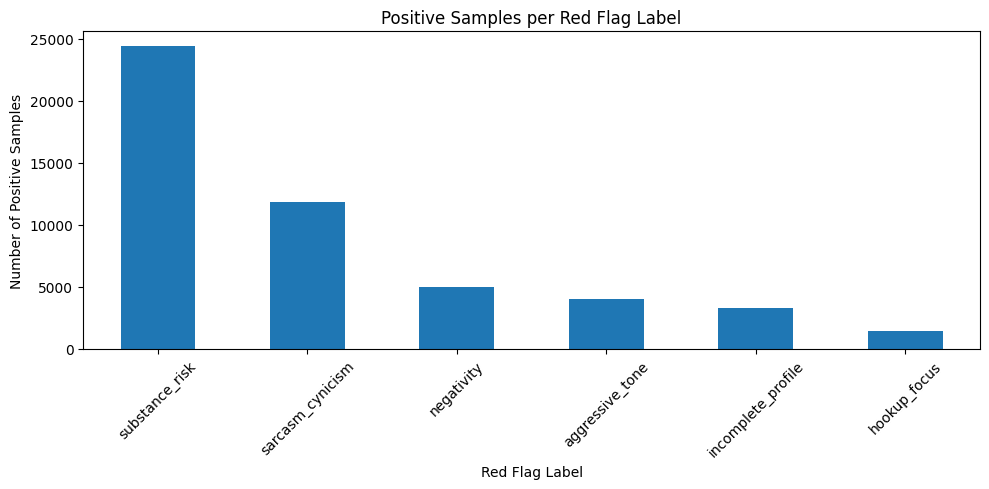

In [6]:
plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Positive Samples per Red Flag Label")
plt.xlabel("Red Flag Label")
plt.ylabel("Number of Positive Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
label_percentages = (y.mean() * 100).sort_values(ascending=False)

label_distribution = pd.DataFrame({
    "positive_count": label_counts,
    "positive_percentage": label_percentages
})

label_distribution

,positive_count,positive_percentage
substance_risk,24390,40.686618
sarcasm_cynicism,11813,19.706069
negativity,4995,8.332499
aggressive_tone,4019,6.704367
incomplete_profile,3323,5.543322
hookup_focus,1467,2.447202


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (47956,)
X_test: (11990,)
y_train: (47956, 6)
y_test: (11990, 6)


In [9]:
train_distribution = pd.DataFrame({
    "train_positive_count": y_train.sum(),
    "test_positive_count": y_test.sum()
})

train_distribution

,train_positive_count,test_positive_count
aggressive_tone,3239,780
hookup_focus,1186,281
negativity,4041,954
sarcasm_cynicism,9464,2349
substance_risk,19541,4849
incomplete_profile,2670,653


In [10]:
tfidf_logreg_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            stop_words="english",
            min_df=3,
            max_df=0.9
        )
    ),
    (
        "classifier",
        MultiOutputClassifier(
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear"
            )
        )
    )
])

In [11]:
tfidf_logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [12]:
y_pred = tfidf_logreg_model.predict(X_test)

y_pred_df = pd.DataFrame(y_pred, columns=label_columns)

y_pred_df.head()

,aggressive_tone,hookup_focus,negativity,sarcasm_cynicism,substance_risk,incomplete_profile
0,0,0,0,1,1,0
1,0,0,1,0,1,0
2,0,0,0,0,0,0
3,0,0,0,0,1,0
4,0,0,0,1,1,0
